## 8 Ball Table Analyses - Task 1 Computer Vision

In [5]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
IMG_DIR = Path("development_set/")
OUTPUT_DIR= Path("output/top_views")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_EXTENSIONS = {".jpg",".jpeg", ".png", ".bmp"}
image_paths = sorted([ path for path in IMG_DIR.iterdir()
                       if path.suffix.lower() in VALID_EXTENSIONS])

print(f"Found {len(image_paths)} images")
for i, path in enumerate(image_paths[:5]):
    print(f"[{i}] {path.name}")


Found 50 images
[0] 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg
[1] 10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg
[2] 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg
[3] 114_png.rf.98b2144c25b9f48816abd7edb00f365c.jpg
[4] 115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg


In [7]:
def show_image(img, title="Image", figsize=(8, 6), cmap=None):
    plt.figure(figsize=figsize)

    if len(img.shape) == 3:
        img_to_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_to_show)
    else:
        plt.imshow(img, cmap=cmap)

    plt.title(title)
    plt.axis("off")
    plt.show()

Loaded: 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg
Shape: (1080, 1920, 3)


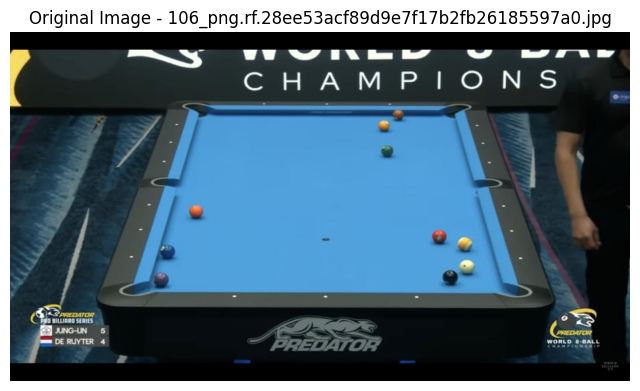

In [8]:
img_idx=0

if not image_paths:
    raise FileNotFoundError(f"No image files found in {IMG_DIR}")

IMAGE_PATH = image_paths[img_idx]
image = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

print("Loaded:", IMAGE_PATH.name)
print("Shape:", image.shape)

show_image(image, f"Original Image - {IMAGE_PATH.name}")

# Approach 1 - Only Using Color

Target BGR: (219, 159, 81)


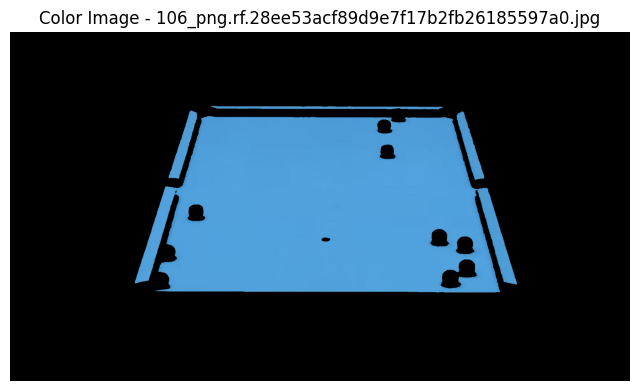

In [9]:
COLOR_TABLE = (206, 66, 59)  # H, S, L

import colorsys

def hsl_to_bgr(h, s, l):
    h = h / 360.0
    s = s / 100.0
    l = l / 100.0

    r, g, b = colorsys.hls_to_rgb(h, l, s)

    r = int(r * 255)
    g = int(g * 255)
    b = int(b * 255)

    return (b, g, r)

target_bgr = hsl_to_bgr(206, 66, 59)
print("Target BGR:", target_bgr)

tolerance = 20

lower = np.array([
    max(target_bgr[0] - tolerance, 0),
    max(target_bgr[1] - tolerance, 0),
    max(target_bgr[2] - tolerance, 0)
], dtype=np.uint8)

upper = np.array([
    min(target_bgr[0] + tolerance, 255),
    min(target_bgr[1] + tolerance, 255),
    min(target_bgr[2] + tolerance, 255)
], dtype=np.uint8)

mask = cv2.inRange(image, lower, upper)

only_table_img = cv2.bitwise_and(image, image, mask=mask)

show_image(only_table_img, f"Color Image - {IMAGE_PATH.name}")

# Approach 2 - Using Lines